In [1]:
import os
import subprocess

# Check if installation was succesful.
try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

# Other imports and helper functions
import time
import itertools
import numpy as np

# Graphics and plotting.
print('Installing mediapy:')
import mediapy as media
%matplotlib widget
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
import ipywidgets as widgets


# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

from IPython.display import clear_output
clear_output()


print(f"MuJoCo {mujoco.__version__}  |  NumPy {np.__version__}")

MuJoCo 3.9.0  |  NumPy 2.4.6


nbody = 2, nv = 1


""

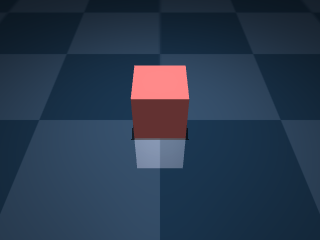

In [2]:
XML = """
<mujoco>
  <asset>
    <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3"
     rgb2=".2 .3 .4" width="300" height="300"/>
    <material name="grid" texture="grid" texrepeat="8 8" reflectance=".2"/>
  </asset>

  <worldbody>
    <geom name="ground" size="10 10 .01" type="plane" material="grid"/>
    <light pos="0 0 5"/>
	<body name="slide_box" pos="0 0 .25">
		<joint name="slide_joint" type="slide" axis="0 1 0"/>
		<geom name="box0" type="box" size=".25 .25 .25" rgba="1 .5 .5 1" mass="5"/>
	</body>
  </worldbody>
    <actuator>
        <!-- Add a general force actuator to apply torque to the joint -->
        <general name="slider" joint="slide_joint" ctrlrange="-1 1"/>
    </actuator>

</mujoco>
"""

model = mujoco.MjModel.from_xml_string(XML)
data  = mujoco.MjData(model)
print(f"nbody = {model.nbody}, nv = {model.nv}")

with mujoco.Renderer(model) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())

In [3]:
# Get mass of the box
box_body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "box0")
mass = model.body_mass[box_body_id]
print(f"Box mass: {mass} kg")

# Apply 1N force using ctrl
force_desired = 1.0  # Newtons along Y-axis
gain = model.actuator_gainprm[0][0]  # Should be 1.0
control_signal = force_desired / gain

print(f"Actuator gain: {gain} N/ctrl")
print(f"Control signal: {control_signal}")
print(f"Applied force: {control_signal * gain} N along Y-axis")
print(f"Theoretical acceleration: a = F/m = {force_desired/mass:.6f} m/s²")


Box mass: 5.0 kg
Actuator gain: 1.0 N/ctrl
Control signal: 1.0
Applied force: 1.0 N along Y-axis
Theoretical acceleration: a = F/m = 0.200000 m/s²


In [4]:
# Storage for plotting
def do_run(model, data, ctrl, duration):

    time_steps = []
    positions = []
    velocities = []
    accelerations = []
    forces_applied = []
    ctrl_signals = []

    # Simulation parameters
    steps = int(duration / model.opt.timestep)
    
    print("\nSimulating with ctrl signal...")
    
    # Apply the control signal
    data.ctrl[0] = ctrl
    
    # Run simulation
    for i in range(steps):
        # Store data
        time_steps.append(data.time)
        positions.append(data.qpos[0])  # Position along axis
        velocities.append(data.qvel[0])  # Velocity along axis
        accelerations.append(data.qacc[0])  # Acceleration along axis
        forces_applied.append(data.ctrl[0] * gain)  # Actual force from actuator
        ctrl_signals.append(data.ctrl[0])  # Control signal
        
        # Step the simulation (force automatically applied via actuator)
        mujoco.mj_step(model, data)
        
        # Print progress
        if i % 200 == 0:
            print(f"t={data.time:.2f}s, pos={data.qpos[0]:.4f}m, vel={data.qvel[0]:.4f}m/s, ctrl={data.ctrl[0]:.3f}")
    print(f"t={data.time:.2f}s, pos={data.qpos[0]:.4f}m, vel={data.qvel[0]:.4f}m/s, ctrl={data.ctrl[0]:.3f}")
    print("\nSimulation complete!")
    return (time_steps, positions, velocities, accelerations, forces_applied, ctrl_signals)

def print_plot(time_steps, positions, velocities, accelerations, forces_applied, ctrl_signals):
    # Convert to numpy arrays
    time_steps = np.array(time_steps)
    positions = np.array(positions)
    velocities = np.array(velocities)
    accelerations = np.array(accelerations)
    forces_applied = np.array(forces_applied)
    ctrl_signals = np.array(ctrl_signals)
    
    # Calculate theoretical values
    theoretical_accel = force_desired / mass
    theoretical_velocity = theoretical_accel * time_steps
    theoretical_position = 0.5 * theoretical_accel * time_steps**2

    # Create plots
    fig, axes = plt.subplots(3, 1, figsize=(10, 8))
    
    # Plot 1: Position
    axes[0].plot(time_steps, positions, 'b-', linewidth=2, label='Simulated')
    axes[0].plot(time_steps, theoretical_position, 'r--', linewidth=2, label='Theoretical')
    axes[0].set_ylabel('Position (m)')
    axes[0].set_title(f'Position vs Time (F = {force_desired}N, m = {mass}kg)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Velocity
    axes[1].plot(time_steps, velocities, 'g-', linewidth=2, label='Simulated')
    axes[1].plot(time_steps, theoretical_velocity, 'r--', linewidth=2, label='Theoretical')
    axes[1].set_ylabel('Velocity (m/s)')
    axes[1].set_title('Velocity vs Time')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Acceleration
    axes[2].plot(time_steps, accelerations, 'r-', linewidth=2, label='Simulated')
    axes[2].axhline(y=theoretical_accel, color='b', linestyle='--', linewidth=2, 
                    label=f'Theoretical ({theoretical_accel:.4f} m/s²)')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('Acceleration (m/s²)')
    axes[2].set_title('Acceleration vs Time')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


Simulating with ctrl signal...
t=0.00s, pos=0.0000m, vel=0.0004m/s, ctrl=1.000
t=0.40s, pos=0.0162m, vel=0.0804m/s, ctrl=1.000
t=0.80s, pos=0.0645m, vel=0.1604m/s, ctrl=1.000
t=1.20s, pos=0.1447m, vel=0.2404m/s, ctrl=1.000
t=1.60s, pos=0.2570m, vel=0.3204m/s, ctrl=1.000
t=2.00s, pos=0.4012m, vel=0.4004m/s, ctrl=1.000
t=2.40s, pos=0.5774m, vel=0.4804m/s, ctrl=1.000
t=2.80s, pos=0.7857m, vel=0.5604m/s, ctrl=1.000
t=3.20s, pos=1.0259m, vel=0.6404m/s, ctrl=1.000
t=3.60s, pos=1.2982m, vel=0.7204m/s, ctrl=1.000
t=4.00s, pos=1.6024m, vel=0.8004m/s, ctrl=1.000
t=4.40s, pos=1.9386m, vel=0.8804m/s, ctrl=1.000
t=4.80s, pos=2.3069m, vel=0.9604m/s, ctrl=1.000
t=5.00s, pos=2.5010m, vel=1.0000m/s, ctrl=1.000

Simulation complete!


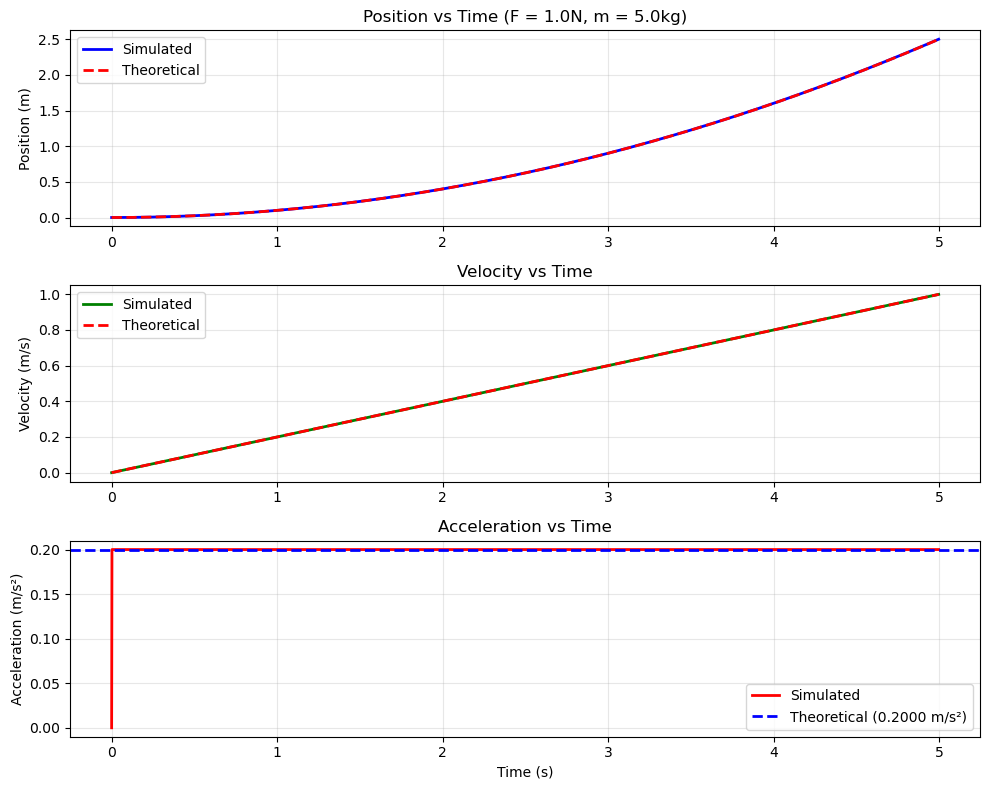

In [5]:
mujoco.mj_resetData(model, data)  # Reset state and time.

time_steps, positions, velocities, accelerations, forces_applied, ctrl_signals = do_run(model, data, control_signal, 5)

print_plot(time_steps, positions, velocities, accelerations, forces_applied, ctrl_signals)

# Forces of Friction

**MuJoCo uses a unified friction model** where:

1. **Same coefficient** applies to both static and kinetic friction
2. **Smooth stiction model** transitions between rest and motion
3. **No stick-slip instability** (numerically stable)
4. **Velocity-dependent smoothing** prevents sudden jumps

In practice, this means:
- If applied force > μ×N → Box moves (overcomes "static" friction)
- If applied force < μ×N → Box stays still (within "static" limit)
- Once moving, friction force remains μ×N (kinetic friction)

So while MuJoCo doesn't distinguish between static and kinetic coefficients, the **behavior mimics both** through its stiction model!

nbody = 2, nv = 6


""

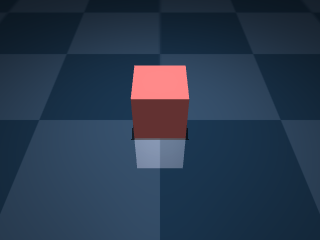

In [6]:
XML = """
<mujoco>
  <asset>
    <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3"
     rgb2=".2 .3 .4" width="300" height="300"/>
    <material name="grid" texture="grid" texrepeat="8 8" reflectance=".2"/>
  </asset>

  <worldbody>
    <geom name="ground" size="10 10 .01" type="plane" material="grid" friction="0.1"/>
    <light pos="0 0 5"/>
	<body name="slide_box" pos="0 0 .25">
		<freejoint name="slide_joint"/>
		<geom name="box0" type="box" size=".25 .25 .25" rgba="1 .5 .5 1" mass="5" friction="0.1"/>
	</body>
  </worldbody>
    <actuator>
        <!-- Add a general force actuator to apply torque to the joint -->
        <general name="slider" joint="slide_joint" ctrlrange="-10 10"/>
    </actuator>

</mujoco>
"""

model = mujoco.MjModel.from_xml_string(XML)
data  = mujoco.MjData(model)
print(f"nbody = {model.nbody}, nv = {model.nv}")

with mujoco.Renderer(model) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())

Original friction values:
  Box friction: [0.1   0.005 0.   ]
  Ground friction: [0.1   0.005 0.   ]

Simulating with ctrl signal...
t=0.00s, pos=0.0000m, vel=0.0004m/s, ctrl=1.000
t=0.40s, pos=0.0000m, vel=0.0001m/s, ctrl=1.000
t=0.80s, pos=0.0000m, vel=0.0001m/s, ctrl=1.000
t=1.20s, pos=0.0001m, vel=0.0001m/s, ctrl=1.000
t=1.60s, pos=0.0001m, vel=0.0001m/s, ctrl=1.000
t=2.00s, pos=0.0001m, vel=0.0001m/s, ctrl=1.000
t=2.40s, pos=0.0001m, vel=0.0001m/s, ctrl=1.000
t=2.80s, pos=0.0002m, vel=0.0001m/s, ctrl=1.000
t=3.20s, pos=0.0002m, vel=0.0001m/s, ctrl=1.000
t=3.60s, pos=0.0002m, vel=0.0001m/s, ctrl=1.000
t=4.00s, pos=0.0002m, vel=0.0001m/s, ctrl=1.000
t=4.40s, pos=0.0002m, vel=0.0001m/s, ctrl=1.000
t=4.80s, pos=0.0003m, vel=0.0001m/s, ctrl=1.000
t=5.00s, pos=0.0003m, vel=0.0001m/s, ctrl=1.000

Simulation complete!


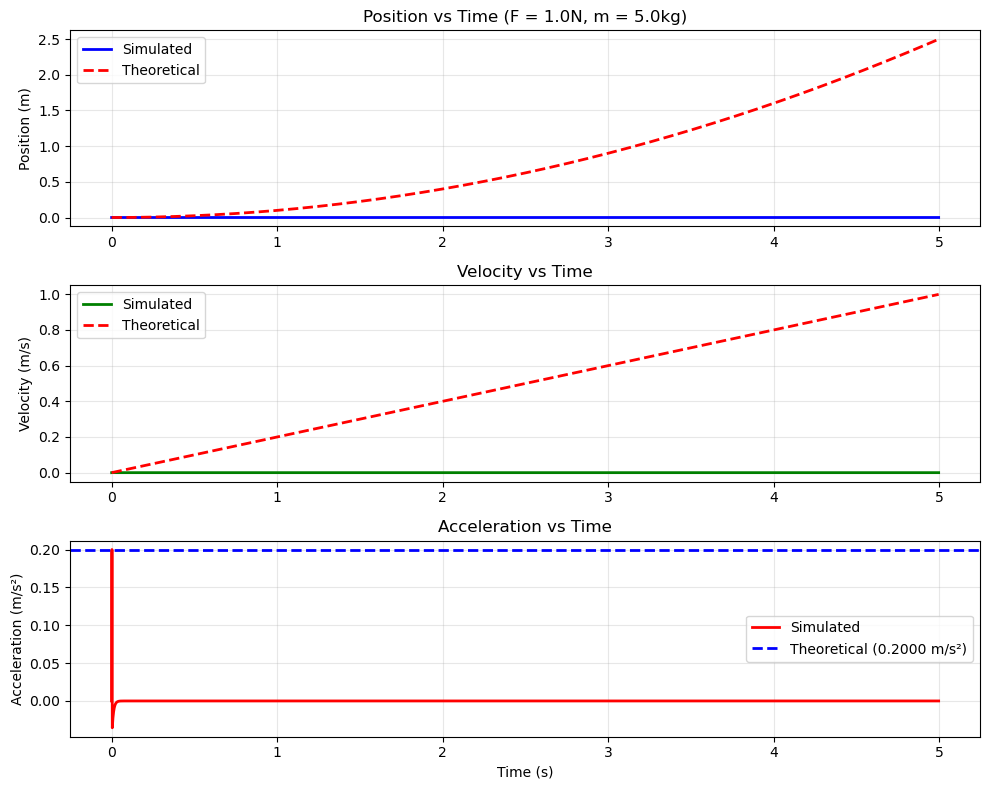

In [7]:
mujoco.mj_resetData(model, data)  # Reset state and time.

# Add Gravity
#model.opt.gravity[2] = -9.81

#Get geom IDs
box_geom_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_GEOM, "box0")
ground_geom_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_GEOM, "ground")

print("Original friction values:")
print(f"  Box friction: {model.geom_friction[box_geom_id]}")
print(f"  Ground friction: {model.geom_friction[ground_geom_id]}")

#GROUND_MU = 0.1
#model.geom_friction[box_geom_id] = GROUND_MU
#model.geom_friction[ground_geom_id] = GROUND_MU
#print("Modified friction values:")
#print(f"  Box friction: {model.geom_friction[box_geom_id]}")
#print(f"  Ground friction: {model.geom_friction[ground_geom_id]}")

# move along X axis
time_steps, positions, velocities, accelerations, forces_applied, ctrl_signals = do_run(model, data, control_signal, 5)

print_plot(time_steps, positions, velocities, accelerations, forces_applied, ctrl_signals)

Gravity: -9.81 m/s²
Friction: -4.905
Desired force: 1.0 N along X-axis
Applied force: 5.905 N along X-axis
Theoretical acceleration: a = F/m = 0.200000 m/s²

Simulating with ctrl signal...
t=0.00s, pos=0.0000m, vel=0.0024m/s, ctrl=5.905
t=0.40s, pos=0.0168m, vel=0.0839m/s, ctrl=5.905
t=0.80s, pos=0.0659m, vel=0.1644m/s, ctrl=5.905
t=1.20s, pos=0.1469m, vel=0.2411m/s, ctrl=5.905
t=1.60s, pos=0.2600m, vel=0.3244m/s, ctrl=5.905
t=2.00s, pos=0.4051m, vel=0.4027m/s, ctrl=5.905
t=2.40s, pos=0.5821m, vel=0.4833m/s, ctrl=5.905
t=2.80s, pos=0.7912m, vel=0.5641m/s, ctrl=5.905
t=3.20s, pos=1.0322m, vel=0.6417m/s, ctrl=5.905
t=3.60s, pos=1.3053m, vel=0.7230m/s, ctrl=5.905
t=4.00s, pos=1.6104m, vel=0.8037m/s, ctrl=5.905
t=4.40s, pos=1.9474m, vel=0.8824m/s, ctrl=5.905
t=4.80s, pos=2.3165m, vel=0.9652m/s, ctrl=5.905
t=5.00s, pos=2.5110m, vel=0.9998m/s, ctrl=5.905

Simulation complete!


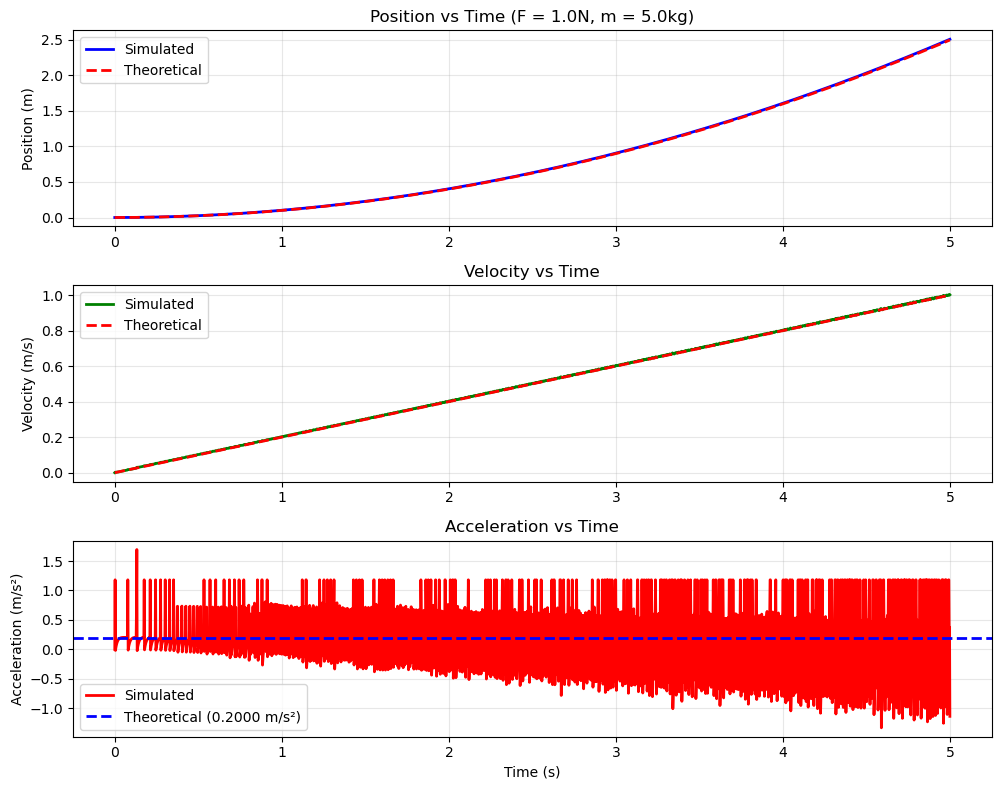

In [10]:
mujoco.mj_resetData(model, data)  # Reset state and time.

# Apply 1N force using ctrl
force_desired = 1.0  # Newtons along Y-axis
gain = model.actuator_gainprm[0][0]  # Should be 1.0

mu = model.geom_friction[box_geom_id][0]
friction = mu * mass * model.opt.gravity[2]
control_signal = (force_desired - friction) / gain

print(f"Gravity: {model.opt.gravity[2]} m/s²")
print(f"Friction: {friction}")
print(f"Desired force: {force_desired} N along X-axis")
print(f"Applied force: {control_signal * gain} N along X-axis")
print(f"Theoretical acceleration: a = F/m = {force_desired/mass:.6f} m/s²")

# move along X axis
time_steps, positions, velocities, accelerations, forces_applied, ctrl_signals = do_run(model, data, control_signal, 5)

print_plot(time_steps, positions, velocities, accelerations, forces_applied, ctrl_signals)